A condição de estabilidade foi satisfeita.
lambda = 0.3094613485101719


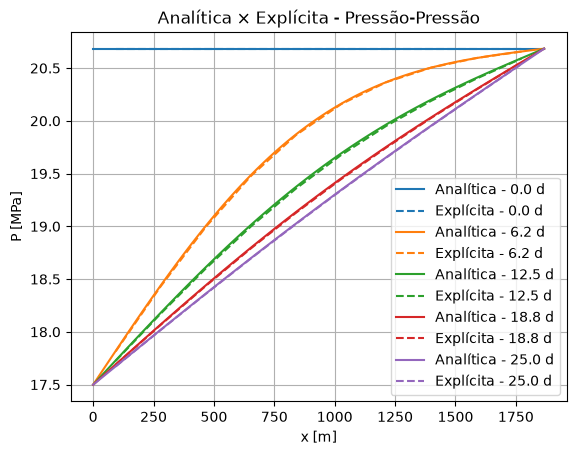

A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.


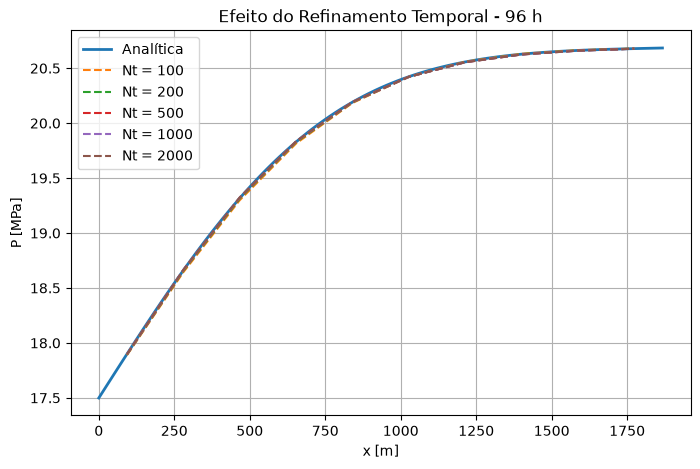

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_PP import linear_trans_1d_PP
from mdf.explicita import explicita_1d_PP


# parâmetros

Pw = 17.499e6             # pressão em x = 0 [Pa]
p0 = 20.684e6             # pressão inicial e pressão em x = L [Pa]

A_R = 3484800             # área do reservatório [m²]
L = np.sqrt(A_R)          # comprimento [m]

k = 339 * 9.869233e-16    # permeabilidade [m²]
phi = 0.22
ct = 3.046e-9
mu = 1.0e-3

t_d = 25                  # tempo final [dias]
t_final = t_d * 86400     # tempo final [s]

n_modos = 100

h = 4.572
largura = L


# solução analítica

x_an, t_an, X, T, P_an = linear_trans_1d_PP(
    p0,
    Pw,
    L,
    k,
    phi,
    ct,
    mu,
    t_final,
    n_modos
)


# solução explícita

nx = 10
nt = 100

x_exp, t_exp, P_exp, lambd = explicita_1d_PP(
    p0,
    Pw,
    h,
    L,
    largura,
    k,
    phi,
    ct,
    mu,
    t_final,
    nx,
    nt
)

print("lambda =", lambd)


# comparação analítica x explícita

tempos_escolhidos = np.linspace(0, t_d, 5)

for tempo in tempos_escolhidos:

    t_escolhido = tempo * 86400

    i_an = np.argmin(
        np.abs(t_an - t_escolhido)
    )

    i_exp = np.argmin(
        np.abs(t_exp - t_escolhido)
    )

    linha, = plt.plot(
        x_an,
        P_an[i_an, :] / 1e6,
        label=f"Analítica - {tempo:.1f} d"
    )

    plt.plot(
        x_exp,
        P_exp[i_exp, :] / 1e6,
        "--",
        color=linha.get_color(),
        label=f"Explícita - {tempo:.1f} d"
    )


plt.xlabel("x [m]")
plt.ylabel("P [MPa]")
plt.title("Analítica × Explícita - Pressão-Pressão")

plt.legend()
plt.grid()
plt.show()


# ==========================================================
# efeito do refinamento temporal
# ==========================================================

nx = 10

nt_values = [
    100,
    200,
    500,
    1000,
    2000
]

tempo_h = 96
t_escolhido = tempo_h * 3600

i_an = np.argmin(
    np.abs(t_an - t_escolhido)
)


# solução analítica

plt.figure(figsize=(8, 5))

plt.plot(
    x_an,
    P_an[i_an, :] / 1e6,
    linewidth=2,
    label="Analítica"
)


# soluções explícitas para diferentes Nt

for nt_i in nt_values:

    x_i, t_i, P_i, lambd_i = explicita_1d_PP(
        p0,
        Pw,
        h,
        L,
        largura,
        k,
        phi,
        ct,
        mu,
        t_final,
        nx,
        nt_i
    )

    i_exp = np.argmin(
        np.abs(t_i - t_escolhido)
    )

    plt.plot(
        x_i,
        P_i[i_exp, :] / 1e6,
        "--",
        label=f"Nt = {nt_i}"
    )


plt.xlabel("x [m]")
plt.ylabel("P [MPa]")
plt.title("Efeito do Refinamento Temporal - 96 h")

plt.legend()
plt.grid()
plt.show()